In [65]:
from landlab.components import ExtendedGravelBedrockEroder
from landlab.components.soil_grading import SoilGrading
from landlab.components import PriorityFloodFlowRouter
from landlab import RasterModelGrid
import matplotlib.pyplot as plt
from landlab.components import BedrockLandslider
import numpy as np
from landlab import imshow_grid

In [35]:
n_rows = 100
n_cols = 3
spacing = 500
init_slope = 0.001
meansizes = [0.03, 0.07] # Two classes of diffrent size
grains_weight = [0, 0]
bed_grains_proportions=[0,1] # Bedrock breaks only into the larger class
phi = 0.4
sediment_density = 2650
runoff_rate=5
elev_jump = 150

In [36]:
# Create grid
grid = RasterModelGrid((n_rows, n_cols), xy_spacing=spacing)

# Create fields
topo = grid.add_zeros('topographic__elevation', at='node')
rock_elev = grid.add_zeros('bedrock__elevation', at='node')
soil_depth = grid.add_zeros('soil__depth', at='node')

In [37]:
# Set boundaries and initial topography
grid.set_watershed_boundary_condition_outlet_id(grid.nodes[0, 1],'topographic__elevation')
rock_elev[:] += grid.y_of_node * init_slope 
rock_elev[grid.core_nodes[50:]]+=elev_jump

In [38]:
sg = SoilGrading(grid,
                 meansizes=meansizes,
                 grains_weight=grains_weight,
                 phi=phi,
                 soil_density=sediment_density)
sg.update_bed_grains_proportions(proportions=bed_grains_proportions)

In [39]:
fa = PriorityFloodFlowRouter(grid,
                             surface="topographic__elevation",
                             accumulate_flow=True,
                             runoff_rate=runoff_rate,
                             flow_metric="D8",
                             separate_hill_flow=True,
                             hill_flow_metric="Quinn",)

In [40]:
# Init EGBE component
intermittency_factor = 0.1
depth_decay_scale = 1
plucking_coefficient = 1
abrasion_coefficients = 0
bedrock_abrasion_coefficient = 0
rho_water = 1000
use_fixed_width = True
fixed_width_coeff = 0.002
fixed_width_expt = 0.5
mannings_n = 0.05
tau_star_c_median = 0.045
alpha = 0.68
tau_c_bedrock = 10
d_min = 0.1
plucking_by_tools_flag = False

# Init eroder
eroder = ExtendedGravelBedrockEroder(grid,
                                     intermittency_factor=intermittency_factor,
                                     sediment_porosity=phi,
                                     depth_decay_scale=depth_decay_scale ,
                                     plucking_coefficient=plucking_coefficient,
                                     abrasion_coefficients=abrasion_coefficients,
                                     bedrock_abrasion_coefficient=bedrock_abrasion_coefficient,
                                     fractions_from_plucking=bed_grains_proportions,
                                     rho_sed=sediment_density,
                                     rho_water=rho_water,
                                     use_fixed_width=use_fixed_width,
                                     fixed_width_coeff=fixed_width_coeff,
                                     fixed_width_expt=fixed_width_expt,
                                     mannings_n=mannings_n,
                                     tau_star_c_median=tau_star_c_median,
                                     alpha=alpha,
                                     tau_c_bedrock=tau_c_bedrock,
                                     d_min=d_min,
                                     plucking_by_tools_flag=plucking_by_tools_flag
                                     )

In [41]:
angle_int_frict=0.01
cohesion_eff=1e2
landslides_return_time=1
landslides_on_boundary_nodes=False
min_deposition_slope = 0.005
threshold_slope=0.5
hy = BedrockLandslider(
    grid,
    angle_int_frict=angle_int_frict,
    cohesion_eff=cohesion_eff,
    landslides_return_time=landslides_return_time,
    rho_r = sediment_density,
    phi = phi,
    landslides_on_boundary_nodes=landslides_on_boundary_nodes,
    min_deposition_slope=min_deposition_slope,
    threshold_slope=threshold_slope)

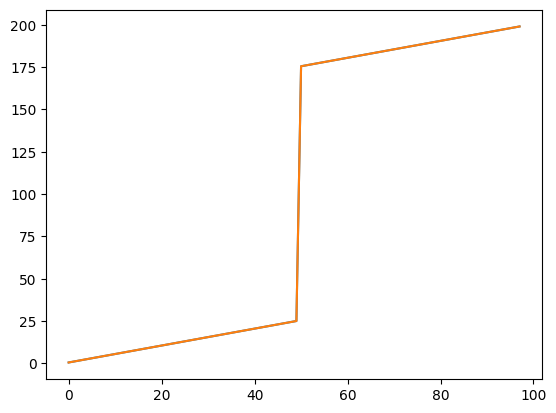

In [42]:
plt.plot(grid.at_node['topographic__elevation'][grid.core_nodes])
plt.plot(grid.at_node['bedrock__elevation'][grid.core_nodes])

In [55]:
for i in range(100):
    fa.run_one_step()
    eroder.run_one_step(1)
    hy.run_one_step(dt=1)
    sg.update_mass_based_on_outsource_dz()


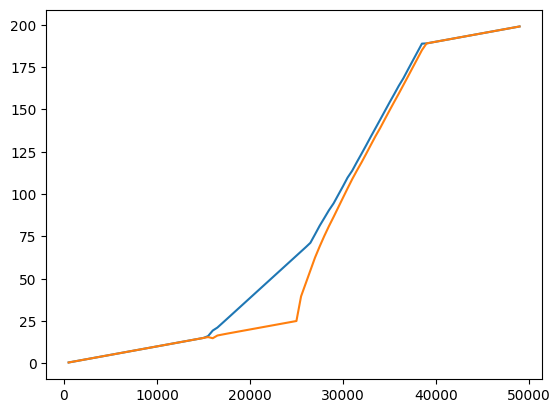

In [56]:
xvec = np.ones_like(grid.at_node['topographic__elevation'][grid.core_nodes])
xvec *= spacing
xvec = np.cumsum(xvec)
plt.plot(xvec,grid.at_node['topographic__elevation'][grid.core_nodes])
plt.plot(xvec,grid.at_node['bedrock__elevation'][grid.core_nodes])
plt.show()

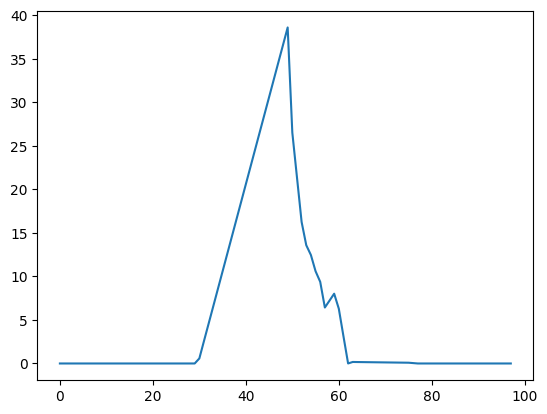

([<matplotlib.lines.Line2D at 0x1754c8f50>], None)

In [29]:
plt.plot(grid.at_node['soil__depth'][grid.core_nodes]),plt.show()

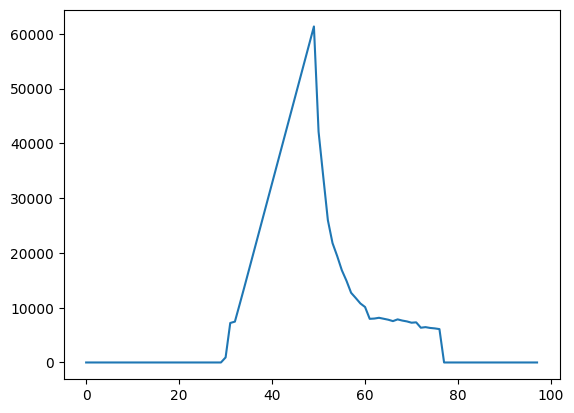

([<matplotlib.lines.Line2D at 0x17b72e850>], None)

In [250]:
plt.plot(grid.at_node['grains__weight'][grid.core_nodes,1]),plt.show()

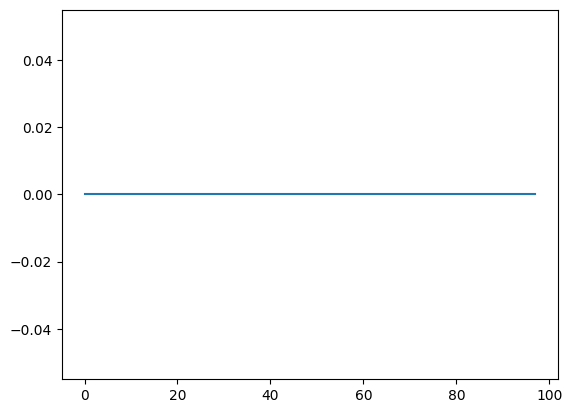

In [32]:
plt.plot(grid.at_node['grains__weight'][grid.core_nodes,0])

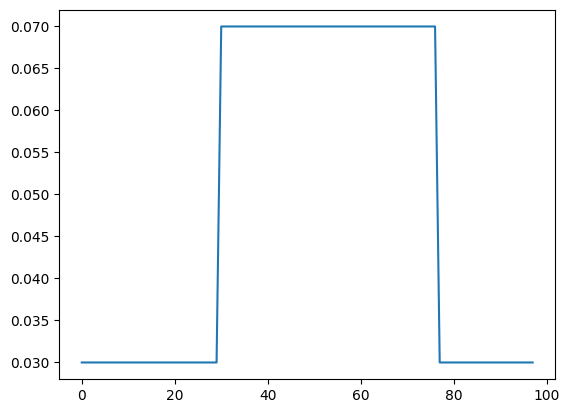

In [33]:
plt.plot(grid.at_node['median_size__weight'][grid.core_nodes])

In [57]:
# Create grid
n_nrows = 200
n_cols = 50

grid2 = RasterModelGrid((n_rows, n_cols), xy_spacing=spacing)

# Create fields
topo = grid2.add_zeros('topographic__elevation', at='node')
rock_elev = grid2.add_zeros('bedrock__elevation', at='node')
soil_depth = grid2.add_zeros('soil__depth', at='node')

In [59]:
grid2.at_node['topographic__elevation']+=grid2.node_y/10

ValueError: operands could not be broadcast together with shapes (300,) (5000,) (300,) 

In [83]:
grid2.at_node['topographic__elevation'][:]=0
grid2.at_node['topographic__elevation']+=grid2.node_y/10
grid2.at_node['topographic__elevation']+=np.abs(np.max(grid2.node_x)/2 - grid2.node_x)/10
grid2.at_node['topographic__elevation'][grid2.nodes[:,25:]]+=150

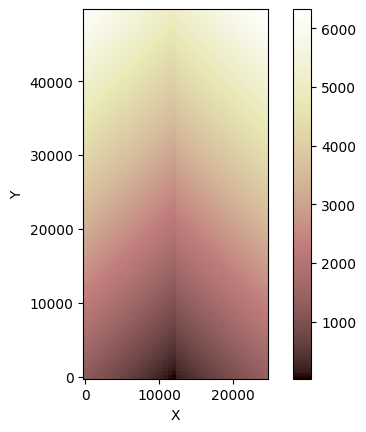

(None, None)

In [84]:
imshow_grid(grid2,'topographic__elevation'),plt.show()

In [208]:
# Set grid parameters
num_rows = 50
num_columns = 50
node_spacing = 25.0

# track sediment flux at the node adjacent to the outlet at lower-left
node_next_to_outlet = num_columns + 1

# Instantiate model grid
mg = RasterModelGrid((num_rows, num_columns), node_spacing)
# add field ’topographic elevation’ to the grid
mg.add_zeros("topographic__elevation", at="node")
# set constant random seed for consistent topographic roughness
np.random.seed(seed=5000)

# Create initial model topography:

# add topographic roughness
random_noise = (
    np.random.rand(len(mg.node_y)) / 1000.0
)  # impose topography values on model grid
mg["node"]["topographic__elevation"] += random_noise

# add field 'soil__depth' to the grid
mg.add_zeros("soil__depth", at="node")

# Set 2 m of initial soil depth at core nodes
mg.at_node["soil__depth"][mg.core_nodes] = 1.0  # meters

# Add field 'bedrock__elevation' to the grid
mg.add_zeros("bedrock__elevation", at="node")

# Sum 'soil__depth' and 'bedrock__elevation'
# to yield 'topographic elevation'
mg.at_node["bedrock__elevation"][:] = mg.at_node["topographic__elevation"]
mg.at_node["topographic__elevation"][:] += mg.at_node["soil__depth"]

In [209]:
# Open all model boundary edges
mg.set_closed_boundaries_at_grid_edges(
    bottom_is_closed=False,
    left_is_closed=False,
    right_is_closed=False,
    top_is_closed=False,
)

In [210]:
# Instantiate flow router
fr = PriorityFloodFlowRouter(mg,
                             surface="topographic__elevation",
                             accumulate_flow=True,
                             runoff_rate=runoff_rate,
                             flow_metric="D8",
                             separate_hill_flow=True,
                             hill_flow_metric="Quinn",)

In [211]:
sg = SoilGrading(mg,
                 meansizes=meansizes,
                 grains_weight=grains_weight,
                 phi=phi,
                 soil_density=sediment_density)
sg.update_bed_grains_proportions(proportions=bed_grains_proportions)

In [212]:
# Init EGBE component
intermittency_factor = 0.1
depth_decay_scale = 1
plucking_coefficient = 1
abrasion_coefficients = 0
bedrock_abrasion_coefficient = 0
rho_water = 1000
use_fixed_width = True
fixed_width_coeff = 0.002
fixed_width_expt = 0.5
mannings_n = 0.05
tau_star_c_median = 0.045
alpha = 0.68
tau_c_bedrock = 10
d_min = 0.1
plucking_by_tools_flag = False

# Init eroder
eroder = ExtendedGravelBedrockEroder(mg,
                                     intermittency_factor=intermittency_factor,
                                     sediment_porosity=phi,
                                     depth_decay_scale=depth_decay_scale ,
                                     plucking_coefficient=plucking_coefficient,
                                     abrasion_coefficients=abrasion_coefficients,
                                     bedrock_abrasion_coefficient=bedrock_abrasion_coefficient,
                                     fractions_from_plucking=bed_grains_proportions,
                                     rho_sed=sediment_density,
                                     rho_water=rho_water,
                                     use_fixed_width=use_fixed_width,
                                     fixed_width_coeff=fixed_width_coeff,
                                     fixed_width_expt=fixed_width_expt,
                                     mannings_n=mannings_n,
                                     tau_star_c_median=tau_star_c_median,
                                     alpha=alpha,
                                     tau_c_bedrock=tau_c_bedrock,
                                     d_min=d_min,
                                     plucking_by_tools_flag=plucking_by_tools_flag
                                     )




In [214]:
angle_int_frict=0.01
cohesion_eff=1e2
landslides_return_time=1
landslides_on_boundary_nodes=False
min_deposition_slope = 0.005
threshold_slope=0.5
hy = BedrockLandslider(
    mg,
    angle_int_frict=angle_int_frict,
    cohesion_eff=cohesion_eff,
    landslides_return_time=landslides_return_time,
    rho_r = sediment_density,
    phi = phi,
    landslides_on_boundary_nodes=landslides_on_boundary_nodes,
    min_deposition_slope=min_deposition_slope,
    threshold_slope=threshold_slope)

2.00 of model run completed


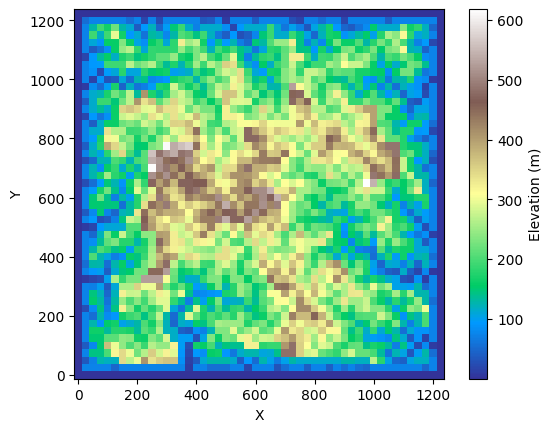

In [217]:
import matplotlib as mpl
# Set model timestep
timestep = 1e5  # years

# Set elapsed time to zero
elapsed_time = 0.0  # years

# Set timestep count to zero
count = 0

# Set model run time
run_time = 5e4  # years

# Array to save sediment flux values
sed_flux = np.zeros(int(run_time // timestep))

# Uplift rate in m/yr
U = 1e-2

cmap = mpl.colormaps["terrain"]
landslides_size_all_steps = []

while elapsed_time < run_time:  # time units of years
    # Insert uplift at core nodes
    mg.at_node["bedrock__elevation"][mg.core_nodes] += U * timestep
    mg.at_node["topographic__elevation"][:] = (
        mg.at_node["bedrock__elevation"] + mg.at_node["soil__depth"]
    )

    # Run the flow router
    fr.run_one_step()

    # Run SPACE for one time step
    eroder.run_one_step(timestep)

    # 
    hy.run_one_step(dt=timestep)
    sg.update_mass_based_on_outsource_dz()
    
    # Add to value of elapsed time
    elapsed_time += timestep



    landslides_size_all_steps = np.append(landslides_size_all_steps, hy.landslides_size)

    if np.mod(elapsed_time, 1e5) == 0:
        print("%.2f of model run completed" % (elapsed_time / run_time))
        imshow_grid(
            mg, "topographic__elevation", cmap=cmap, colorbar_label="Elevation (m)"
        )
        plt.show()

In [218]:
landslides_size_all_steps

array([], dtype=float64)

2.00 of model run completed


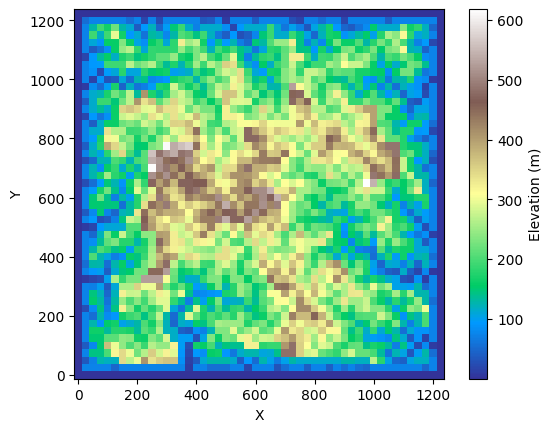

In [219]:
print("%.2f of model run completed" % (elapsed_time / run_time))
imshow_grid(
    mg, "topographic__elevation", cmap=cmap, colorbar_label="Elevation (m)"
)
plt.show()

2.00 of model run completed


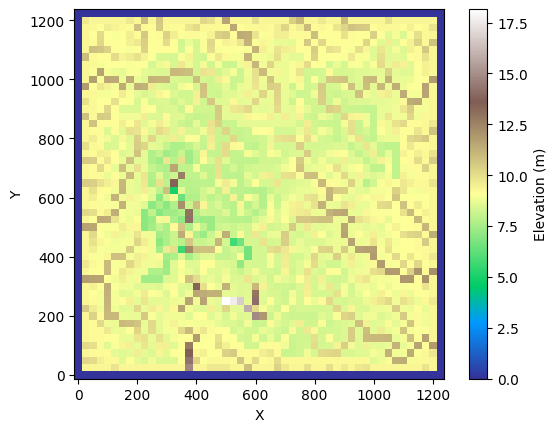

In [220]:
print("%.2f of model run completed" % (elapsed_time / run_time))
imshow_grid(
    mg, "soil__depth", cmap=cmap, colorbar_label="Elevation (m)"
)
plt.show()

In [147]:
mg.at_node["topographic__steepest_slope"]+=50


In [153]:
hy.run_one_step(dt=timestep*10)

(0.0, np.float64(0.0))

In [146]:
13/500

0.026

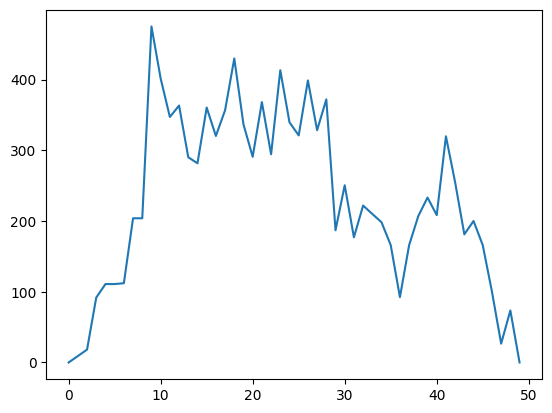

([<matplotlib.lines.Line2D at 0x17b350e10>], None)

In [221]:
plt.plot(mg.at_node['topographic__elevation'][mg.nodes][20,:]),plt.show()

In [156]:
mg.at_node['topographic__elevation'][grid.nodes][20,:]

array([74.82915005, 74.82941134, 74.82971477])

In [238]:
topo = hy.grid.at_node["topographic__elevation"]
bed = hy.grid.at_node["bedrock__elevation"]
steepest_slope = hy.grid.at_node["topographic__steepest_slope"]
soil_d = hy.grid.at_node["soil__depth"]
landslide_sed_in = hy.grid.at_node["landslide_sediment_point_source"]
landslide__ero = hy.grid.at_node["landslide__erosion"]


In [240]:
steepest_slope  = hy.grid.at_node['topographic__steepest_slope']
# height_cell[flooded_nodes] = 0
# height_cell[height_cell > MAX_HEIGHT_SLOPE] = MAX_HEIGHT_SLOPE

angle_int_frict_radians = np.arctan(angle_int_frict)
height_critical = np.divide(
    (4 * cohesion_eff / (9.81 * 2650))
    * (np.sin(np.arctan(steepest_slope)) * np.cos(angle_int_frict_radians)),
    1 - np.cos(np.arctan(steepest_slope) - angle_int_frict_radians),
    where=(1 - np.cos(np.arctan(steepest_slope) - angle_int_frict_radians))
    > 0,
    out=np.zeros_like(steepest_slope),
)

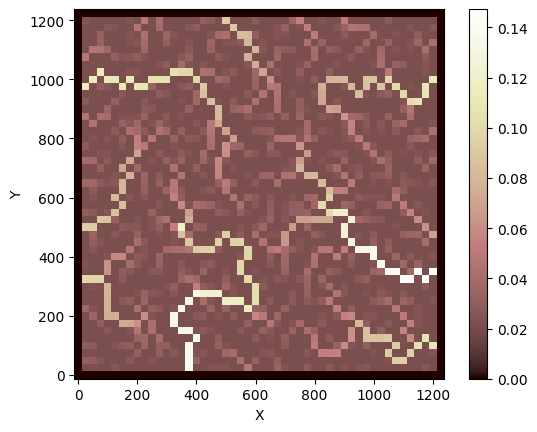

(None, None)

In [241]:
imshow_grid(mg,height_critical),plt.show()

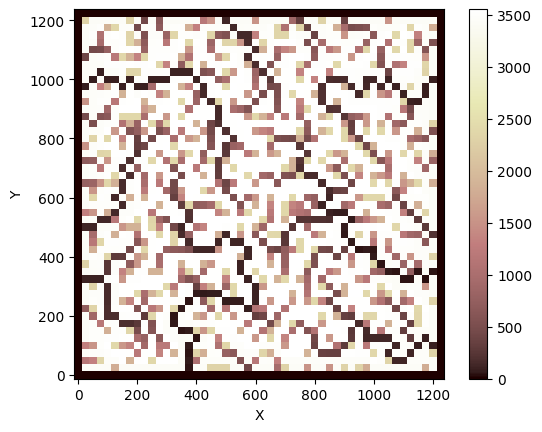

(None, None)

In [242]:
imshow_grid(mg,np.divide(height_cell,height_critical,where=height_critical>0)),plt.show()

In [243]:
spatial_prob = np.divide(
    height_cell,
    height_critical,
    where=height_critical > 0,
    out=np.zeros_like(height_critical),
)
spatial_prob[np.arctan(steepest_slope) <= angle_int_frict_radians] = 0
spatial_prob[spatial_prob > 1] = 1


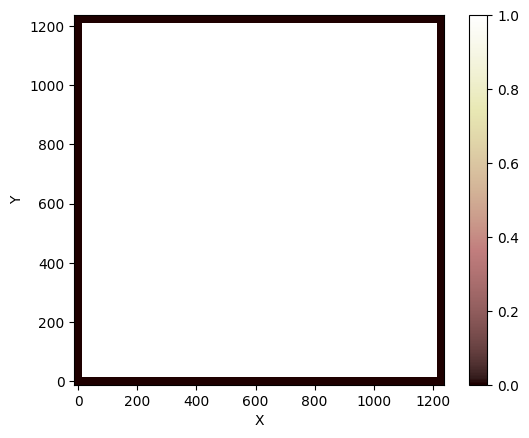

(None, None)

In [244]:
imshow_grid(mg,spatial_prob),plt.show()

In [245]:
# Temporal probability
dt=timestep
temporal_prob = 1 - np.exp(-dt / hy._landslides_return_time)

# Combined probability
combined_prob = temporal_prob * spatial_prob
sliding = np.random.rand(combined_prob.size) < combined_prob

# Now, find the critical node, which is the receiver of critical_landslide_nodes
# Critical nodes must be unique (a given node can have more receivers...)
critical_landslide_nodes = np.unique(
    mg.at_node["flow__receiver_node"][np.where(sliding)]
)

 # Remove boundary nodes
if not hy._landslides_on_boundary_nodes:
    critical_landslide_nodes = critical_landslide_nodes[
        ~mg.node_is_boundary(critical_landslide_nodes)
    ]

In [248]:
hy.run_one_step(dt=timestep)
hy._landslides_size

[]

In [184]:
np.max(mg.at_node['landslide__erosion'])

np.float64(0.0)

In [197]:
hy._critical_sliding_nodes  = critical_landslide_nodes
hy._critical_sliding_nodes

array([  55,   65,   68,   69,   70,   73,   77,   78,   81,   84,   86,
         88,   89,   97,  101,  102,  103,  107,  110,  115,  116,  122,
        124,  127,  142,  143,  144,  158,  161,  163,  165,  166,  167,
        170,  171,  175,  176,  181,  183,  184,  185,  190,  192,  195,
        198,  201,  202,  205,  206,  207,  209,  211,  212,  215,  219,
        220,  228,  232,  235,  236,  237,  239,  243,  246,  248,  258,
        259,  261,  266,  269,  274,  276,  278,  282,  284,  287,  289,
        290,  291,  292,  295,  297,  304,  307,  308,  310,  314,  315,
        316,  317,  318,  322,  325,  326,  329,  331,  332,  337,  339,
        341,  344,  353,  356,  357,  358,  360,  363,  373,  376,  377,
        379,  380,  383,  388,  389,  392,  395,  396,  402,  404,  405,
        409,  410,  413,  416,  417,  419,  421,  424,  425,  427,  433,
        435,  436,  437,  439,  440,  444,  446,  451,  452,  454,  458,
        460,  461,  463,  464,  468,  470,  473,  4

In [198]:
hy._landslide_erosion(dt=timestep)

np.float64(0.0)